In [75]:
from scipy.io import arff
import pandas as pd

In [76]:
dfs = []
for i in range(1, 6):
    file_path = f"{i}year.arff"
    data, meta = arff.loadarff(file_path)
    temp_df = pd.DataFrame(data)
    
    temp_df = temp_df.map(lambda x: x.decode() if isinstance(x, bytes) else x)
    
    temp_df["Year"] = i
    dfs.append(temp_df)

df = pd.concat(dfs, ignore_index=True)

df = df.apply(pd.to_numeric, errors="ignore")

C:\Users\ozgek\AppData\Local\Temp\ipykernel_11120\385219679.py:14: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")


In [77]:
print(f"Toplam veri boyutu: {df.shape}")

Toplam veri boyutu: (43405, 66)


In [78]:
df.to_csv("polish_dataset_merged.csv", index=False)

In [79]:
df.isnull().sum().sort_values(ascending=False).head(20)

Attr37    18984
Attr21     5854
Attr27     2764
Attr60     2152
Attr45     2147
Attr24      922
Attr64      812
Attr53      812
Attr54      812
Attr28      812
Attr41      754
Attr32      368
Attr52      301
Attr47      297
Attr46      135
Attr63      134
Attr40      134
Attr4       134
Attr33      134
Attr12      134
dtype: int64

In [80]:
!pip install missingno

C:\Users\ozgek\AppData\Local\Temp\ipykernel_11120\4041708029.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_10_missing.values, y=top_10_missing.index, palette="Reds_r")


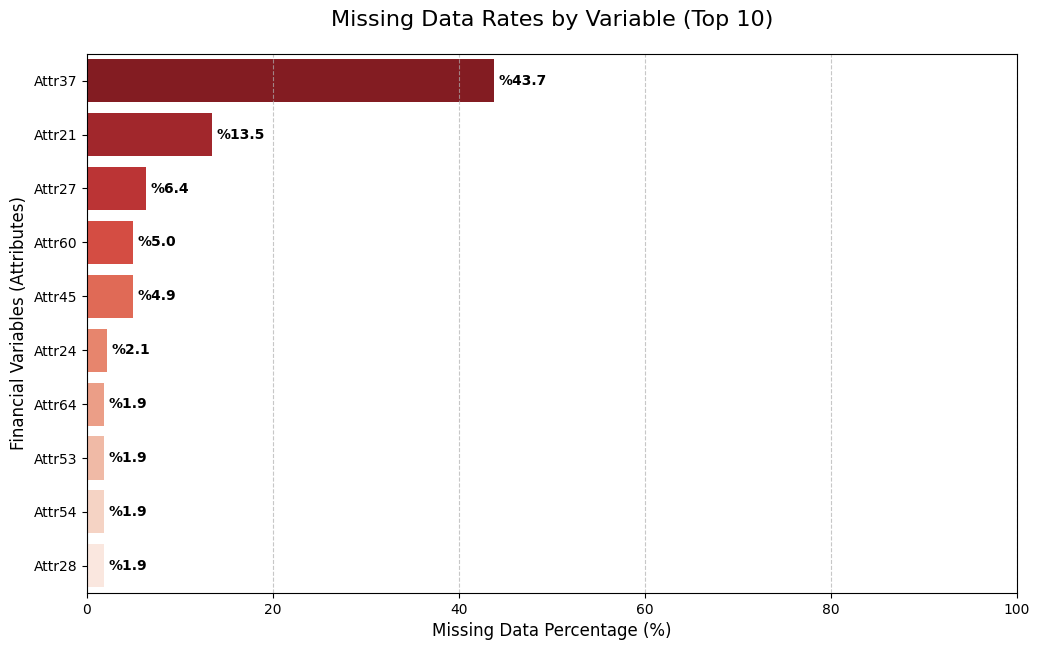

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

missing_percent = (df.isnull().sum() / len(df)) * 100

top_10_missing = missing_percent.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=top_10_missing.values, y=top_10_missing.index, palette="Reds_r")

for i, v in enumerate(top_10_missing.values):
    ax.text(v + 0.5, i, f'%{v:.1f}', va='center', fontweight='bold')

plt.title("Missing Data Rates by Variable (Top 10)", fontsize=16, pad=20)
plt.xlabel("Missing Data Percentage (%)", fontsize=12)
plt.ylabel("Financial Variables (Attributes)", fontsize=12)
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

In [82]:
df.dtypes.value_counts()

float64    64
int64       2
Name: count, dtype: int64

In [83]:
df.select_dtypes(include="object").head()

""
0
1
2
3
4


In [84]:
df = df.apply(pd.to_numeric, errors="ignore")

C:\Users\ozgek\AppData\Local\Temp\ipykernel_11120\3400095637.py:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")


In [85]:
df = df.drop(columns=["Attr37"])

In [86]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["class"])
y = df["class"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.value_counts(), y_test.value_counts()

((34724, 64),
 (8681, 64),
 class
 0    33051
 1     1673
 Name: count, dtype: int64,
 class
 0    8263
 1     418
 Name: count, dtype: int64)

In [87]:
import numpy as np

cols = [c for c in X_train.columns if c not in ["Year"]]

year_medians = {col: X_train.groupby("Year")[col].median() for col in cols}
global_medians = {col: X_train[col].median() for col in cols}

def fill_year_median(X_):
    X_ = X_.copy()
    for col in cols:
        X_[col] = X_[col].fillna(X_["Year"].map(year_medians[col]))
        X_[col] = X_[col].fillna(global_medians[col])
    return X_

X_train_ym = fill_year_median(X_train)
X_test_ym  = fill_year_median(X_test)

In [88]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imp = IterativeImputer(max_iter=20, random_state=42)

X_train_num = X_train_ym.drop(columns=["Year"])
X_test_num  = X_test_ym.drop(columns=["Year"])

X_train_imp = imp.fit_transform(X_train_num)
X_test_imp  = imp.transform(X_test_num)

X_train_imp = pd.DataFrame(X_train_imp, columns=X_train_num.columns, index=X_train_num.index)
X_test_imp  = pd.DataFrame(X_test_imp,  columns=X_test_num.columns,  index=X_test_num.index)


In [89]:
X_train_final = X_train_imp.copy()
X_test_final  = X_test_imp.copy()

X_train_final["Year"] = X_train_ym["Year"].values
X_test_final["Year"]  = X_test_ym["Year"].values

X_train_final.shape, X_test_final.shape

((34724, 64), (8681, 64))

In [90]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled  = scaler.transform(X_test_final)

In [91]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

y_train.value_counts(), y_train_res.value_counts()

(class
 0    33051
 1     1673
 Name: count, dtype: int64,
 class
 0    33051
 1    33051
 Name: count, dtype: int64)

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

model_log_reg = LogisticRegression(
    max_iter=1000,
    solver="lbfgs"  
)

model_log_reg.fit(X_train_res, y_train_res)

y_proba_log = model_log_reg.predict_proba(X_test_scaled)[:, 1]

y_pred_log = (y_proba_log >= 0.5).astype(int)

print("Logistic Regression Sonuçları\n")
print(classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

print("\nROC-AUC :", roc_auc_score(y_test, y_proba_log))
print("PR-AUC  :", average_precision_score(y_test, y_proba_log))

Logistic Regression Sonuçları

              precision    recall  f1-score   support

           0       0.97      0.73      0.83      8263
           1       0.10      0.61      0.17       418

    accuracy                           0.72      8681
   macro avg       0.54      0.67      0.50      8681
weighted avg       0.93      0.72      0.80      8681

Confusion Matrix:
 [[6006 2257]
 [ 165  253]]

ROC-AUC : 0.7279644023307915
PR-AUC  : 0.13044947727680734


In [93]:
thresholds = [0.4, 0.3, 0.2, 0.1]

for t in thresholds:
    y_pred_t = (y_proba_log >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred_t, digits=3))


Threshold = 0.4
              precision    recall  f1-score   support

           0      0.981     0.417     0.585      8263
           1      0.068     0.844     0.126       418

    accuracy                          0.438      8681
   macro avg      0.525     0.631     0.356      8681
weighted avg      0.938     0.438     0.563      8681


Threshold = 0.3
              precision    recall  f1-score   support

           0      0.988     0.177     0.301      8263
           1      0.056     0.957     0.105       418

    accuracy                          0.215      8681
   macro avg      0.522     0.567     0.203      8681
weighted avg      0.943     0.215     0.291      8681


Threshold = 0.2
              precision    recall  f1-score   support

           0      0.990     0.072     0.134      8263
           1      0.051     0.986     0.097       418

    accuracy                          0.116      8681
   macro avg      0.521     0.529     0.116      8681
weighted avg      0.945

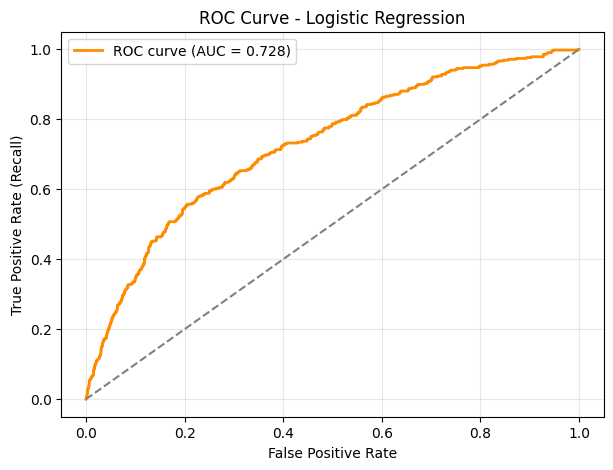

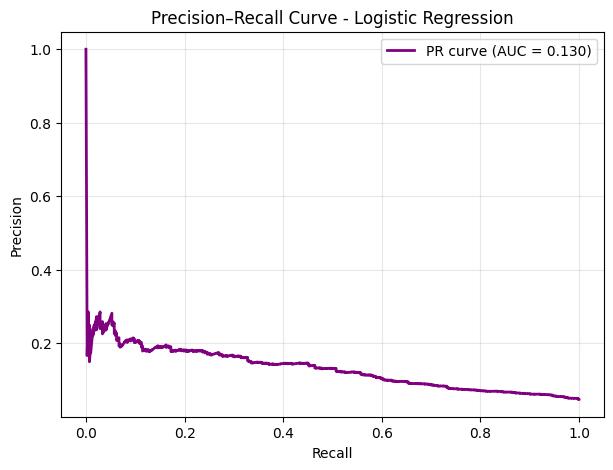

In [94]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve,
    average_precision_score,
    precision_score, recall_score
)

fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba_log)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, lw=2, color="darkorange",
         label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba_log)
pr_auc = average_precision_score(y_test, y_proba_log)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, lw=2, color="purple",
         label=f"PR curve (AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

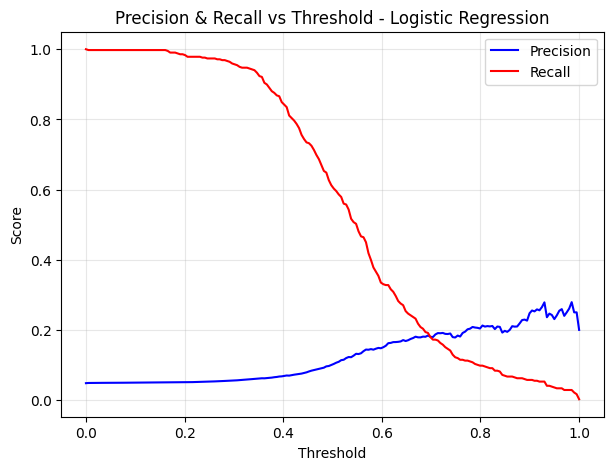

ROC-AUC  : 0.728
PR-AUC   : 0.130


In [95]:
ths = np.linspace(0.0, 1.0, 200)
precisions = []
recalls = []

for t in ths:
    y_pred_t = (y_proba_log >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t))

plt.figure(figsize=(7,5))
plt.plot(ths, precisions, label="Precision", color="blue")
plt.plot(ths, recalls, label="Recall", color="red")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold - Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"ROC-AUC  : {roc_auc:.3f}")
print(f"PR-AUC   : {pr_auc:.3f}")


In [96]:
from lightgbm import LGBMClassifier

model_lgbm = LGBMClassifier(
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model_lgbm.fit(X_train_res, y_train_res)

y_proba_lgbm = model_lgbm.predict_proba(X_test_scaled)[:, 1]
y_pred_lgbm  = (y_proba_lgbm >= 0.5).astype(int)

print("LightGBM Sonuçları (Complex Polish Dataset)\n")
print(classification_report(y_test, y_pred_lgbm, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lgbm))

print("\nROC-AUC :", roc_auc_score(y_test, y_proba_lgbm))
print("PR-AUC  :", average_precision_score(y_test, y_proba_lgbm))


[LightGBM] [Info] Number of positive: 33051, number of negative: 33051
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025542 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16320
[LightGBM] [Info] Number of data points in the train set: 66102, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\ozgek\.conda\envs\tf310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Sonuçları (Complex Polish Dataset)

              precision    recall  f1-score   support

           0      0.984     0.994     0.989      8263
           1      0.847     0.677     0.753       418

    accuracy                          0.979      8681
   macro avg      0.916     0.835     0.871      8681
weighted avg      0.977     0.979     0.977      8681

Confusion Matrix:
 [[8212   51]
 [ 135  283]]

ROC-AUC : 0.9757308622573565
PR-AUC  : 0.8258637252473464


In [97]:
thresholds = [0.4, 0.3, 0.2, 0.1]
for t in thresholds:
    y_pred_lgbm_thr = (y_proba_lgbm >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred_lgbm_thr, digits=3))
    print(confusion_matrix(y_test, y_pred_lgbm_thr))



Threshold = 0.4
              precision    recall  f1-score   support

           0      0.986     0.989     0.987      8263
           1      0.759     0.718     0.738       418

    accuracy                          0.975      8681
   macro avg      0.873     0.853     0.863      8681
weighted avg      0.975     0.975     0.975      8681

[[8168   95]
 [ 118  300]]

Threshold = 0.3
              precision    recall  f1-score   support

           0      0.989     0.981     0.985      8263
           1      0.673     0.787     0.725       418

    accuracy                          0.971      8681
   macro avg      0.831     0.884     0.855      8681
weighted avg      0.974     0.971     0.972      8681

[[8103  160]
 [  89  329]]

Threshold = 0.2
              precision    recall  f1-score   support

           0      0.992     0.964     0.978      8263
           1      0.543     0.840     0.660       418

    accuracy                          0.958      8681
   macro avg      0.768

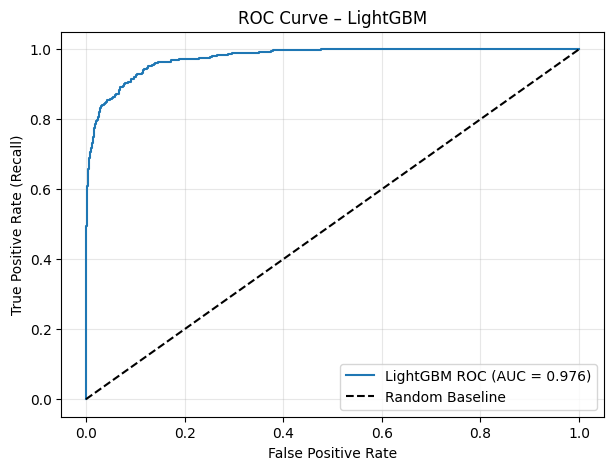

In [98]:
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_proba_lgbm)
roc_auc_lgbm = roc_auc_score(y_test, y_proba_lgbm)

plt.figure(figsize=(7,5))
plt.plot(fpr_lgbm, tpr_lgbm, label=f"LightGBM ROC (AUC = {roc_auc_lgbm:.3f})")
plt.plot([0,1], [0,1], "k--", label="Random Baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve – LightGBM")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

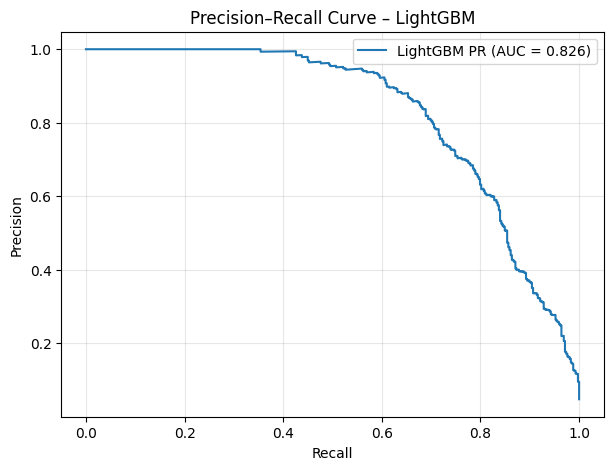

In [99]:
precision_lgbm, recall_lgbm, _ = precision_recall_curve(y_test, y_proba_lgbm)
pr_auc_lgbm = average_precision_score(y_test, y_proba_lgbm)

plt.figure(figsize=(7,5))
plt.plot(recall_lgbm, precision_lgbm, label=f"LightGBM PR (AUC = {pr_auc_lgbm:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – LightGBM")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


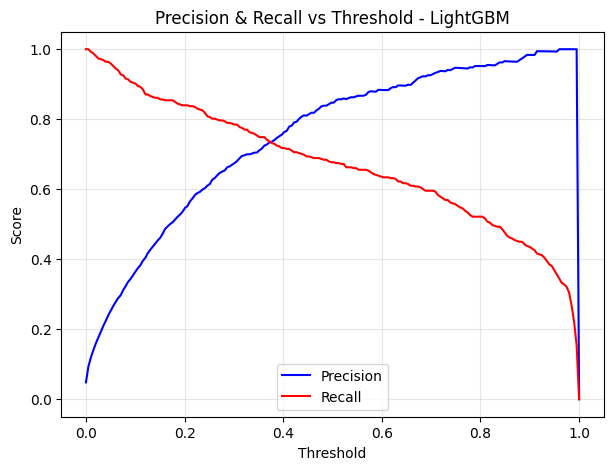

LightGBM ROC-AUC  : 0.976
LightGBM PR-AUC   : 0.826


In [100]:
ths = np.linspace(0.0, 1.0, 200)
precisions = []
recalls = []

for t in ths:
    y_pred_t = (y_proba_lgbm >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t))

plt.figure(figsize=(7,5))
plt.plot(ths, precisions, label="Precision", color="blue")
plt.plot(ths, recalls, label="Recall", color="red")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold - LightGBM")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

roc_auc = roc_auc_score(y_test, y_proba_lgbm)
pr_auc  = average_precision_score(y_test, y_proba_lgbm)

print(f"LightGBM ROC-AUC  : {roc_auc:.3f}")
print(f"LightGBM PR-AUC   : {pr_auc:.3f}")

In [101]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train_res, y_train_res)

y_proba_rf = model_rf.predict_proba(X_test_scaled)[:, 1]
y_pred_rf = (y_proba_rf >= 0.5).astype(int)

print("Random Forest Sonuçları\n")
print(classification_report(y_test, y_pred_rf, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

print("\nROC-AUC :", roc_auc_score(y_test, y_proba_rf))
print("PR-AUC  :", average_precision_score(y_test, y_proba_rf))


Random Forest Sonuçları

              precision    recall  f1-score   support

           0      0.977     0.975     0.976      8263
           1      0.524     0.550     0.537       418

    accuracy                          0.954      8681
   macro avg      0.751     0.762     0.756      8681
weighted avg      0.955     0.954     0.955      8681

Confusion Matrix:
 [[8054  209]
 [ 188  230]]

ROC-AUC : 0.927594013087685
PR-AUC  : 0.5651534249910201


In [102]:
thresholds = [0.4, 0.3, 0.2, 0.1]

for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred_t, digits=3))


Threshold = 0.4
              precision    recall  f1-score   support

           0      0.983     0.942     0.962      8263
           1      0.373     0.684     0.483       418

    accuracy                          0.929      8681
   macro avg      0.678     0.813     0.722      8681
weighted avg      0.954     0.929     0.939      8681


Threshold = 0.3
              precision    recall  f1-score   support

           0      0.990     0.874     0.928      8263
           1      0.247     0.821     0.380       418

    accuracy                          0.871      8681
   macro avg      0.619     0.847     0.654      8681
weighted avg      0.954     0.871     0.902      8681


Threshold = 0.2
              precision    recall  f1-score   support

           0      0.994     0.743     0.850      8263
           1      0.152     0.911     0.261       418

    accuracy                          0.751      8681
   macro avg      0.573     0.827     0.555      8681
weighted avg      0.953

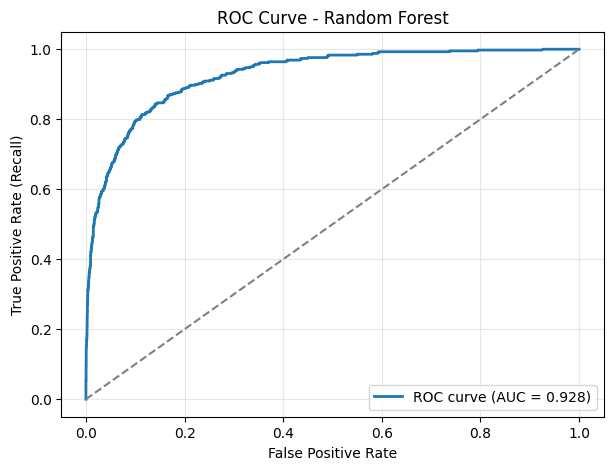

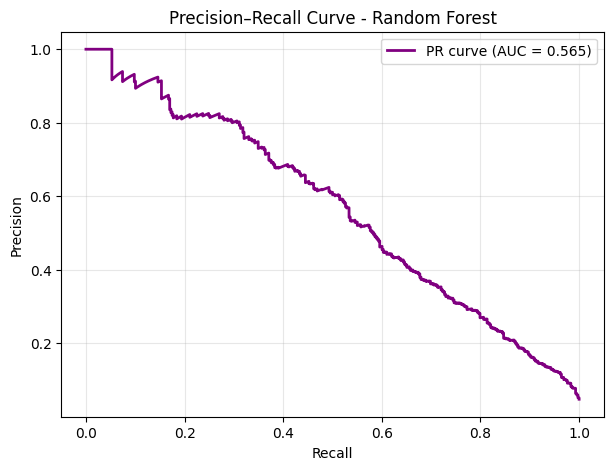

In [103]:
fpr_rf, tpr_rf, thr = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(7,5))
plt.plot(fpr_rf, tpr_rf, lw=2, label=f"ROC curve (AUC = {roc_auc_rf:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

precision_rf, recall_rf, thr_pr = precision_recall_curve(y_test, y_proba_rf)
pr_auc_rf = average_precision_score(y_test, y_proba_rf)

plt.figure(figsize=(7,5))
plt.plot(recall_rf, precision_rf, lw=2,
         label=f"PR curve (AUC = {pr_auc_rf:.3f})",
         color="purple")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


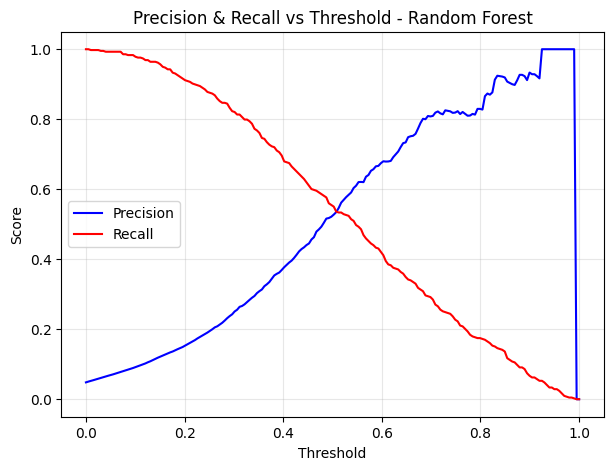

In [104]:
ths = np.linspace(0.0, 1.0, 200)
precisions = []
recalls = []

for t in ths:
    y_pred_t = (y_proba_rf >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t))

plt.figure(figsize=(7,5))
plt.plot(ths, precisions, label="Precision", color="blue")
plt.plot(ths, recalls, label="Recall", color="red")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold - Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [105]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model_xgb.fit(X_train_res, y_train_res)

y_proba_xgb = model_xgb.predict_proba(X_test_scaled)[:, 1]
y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)

print("\nXGBoost Sonuçları\n")
print(classification_report(y_test, y_pred_xgb, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

print("\nROC-AUC :", roc_auc_score(y_test, y_proba_xgb))
print("PR-AUC  :", average_precision_score(y_test, y_proba_xgb))


XGBoost Sonuçları

              precision    recall  f1-score   support

           0      0.985     0.985     0.985      8263
           1      0.701     0.701     0.701       418

    accuracy                          0.971      8681
   macro avg      0.843     0.843     0.843      8681
weighted avg      0.971     0.971     0.971      8681

Confusion Matrix:
 [[8138  125]
 [ 125  293]]

ROC-AUC : 0.9643667192250924
PR-AUC  : 0.7802526955570037


In [106]:
thresholds = [0.4, 0.3, 0.2, 0.1]

for t in thresholds:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred_t, digits=3))


Threshold = 0.4
              precision    recall  f1-score   support

           0      0.987     0.972     0.979      8263
           1      0.574     0.754     0.651       418

    accuracy                          0.961      8681
   macro avg      0.781     0.863     0.815      8681
weighted avg      0.967     0.961     0.964      8681


Threshold = 0.3
              precision    recall  f1-score   support

           0      0.990     0.949     0.969      8263
           1      0.444     0.809     0.573       418

    accuracy                          0.942      8681
   macro avg      0.717     0.879     0.771      8681
weighted avg      0.964     0.942     0.950      8681


Threshold = 0.2
              precision    recall  f1-score   support

           0      0.993     0.908     0.949      8263
           1      0.324     0.871     0.472       418

    accuracy                          0.906      8681
   macro avg      0.658     0.889     0.711      8681
weighted avg      0.961

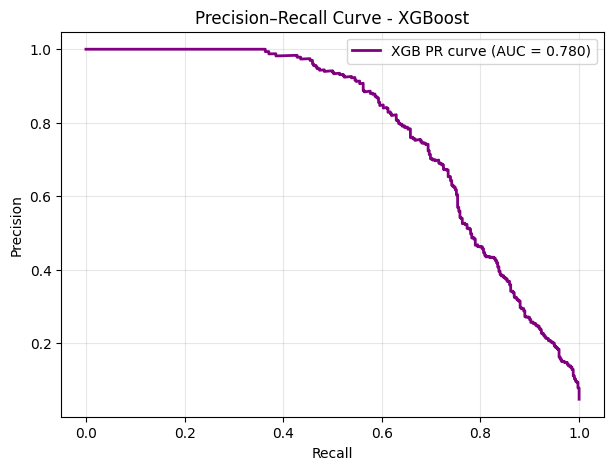

In [107]:
precision_xgb, recall_xgb, thr_pr_xgb = precision_recall_curve(y_test, y_proba_xgb)
pr_auc_xgb = average_precision_score(y_test, y_proba_xgb)

plt.figure(figsize=(7,5))
plt.plot(recall_xgb, precision_xgb, lw=2,
         label=f"XGB PR curve (AUC = {pr_auc_xgb:.3f})",
         color="purple")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - XGBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

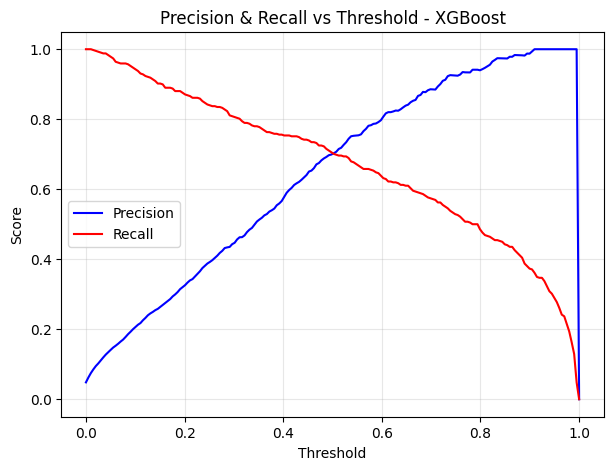

In [108]:
ths = np.linspace(0.0, 1.0, 200)
precisions = []
recalls = []

for t in ths:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t))

plt.figure(figsize=(7,5))
plt.plot(ths, precisions, label="Precision", color="blue")
plt.plot(ths, recalls, label="Recall", color="red")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold - XGBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [109]:
from catboost import CatBoostClassifier

model_cb = CatBoostClassifier(
    iterations=400,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0
)

model_cb.fit(X_train_res, y_train_res)

y_proba_cb = model_cb.predict_proba(X_test_scaled)[:, 1]
y_pred_cb  = (y_proba_cb >= 0.5).astype(int)

print("CatBoost Sonuçları\n")
print(classification_report(y_test, y_pred_cb, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_cb))

print("\nROC-AUC :", roc_auc_score(y_test, y_proba_cb))
print("PR-AUC  :", average_precision_score(y_test, y_proba_cb))

CatBoost Sonuçları

              precision    recall  f1-score   support

           0      0.984     0.971     0.978      8263
           1      0.549     0.689     0.611       418

    accuracy                          0.958      8681
   macro avg      0.766     0.830     0.794      8681
weighted avg      0.963     0.958     0.960      8681

Confusion Matrix:
 [[8026  237]
 [ 130  288]]

ROC-AUC : 0.9560732776017146
PR-AUC  : 0.7234624845347631


In [110]:
thresholds = [0.4, 0.3, 0.2, 0.1]

for t in thresholds:
    y_pred_t = (y_proba_cb >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred_t, digits=3))



Threshold = 0.4
              precision    recall  f1-score   support

           0      0.988     0.947     0.967      8263
           1      0.426     0.780     0.551       418

    accuracy                          0.939      8681
   macro avg      0.707     0.863     0.759      8681
weighted avg      0.961     0.939     0.947      8681


Threshold = 0.3
              precision    recall  f1-score   support

           0      0.992     0.906     0.947      8263
           1      0.316     0.854     0.461       418

    accuracy                          0.904      8681
   macro avg      0.654     0.880     0.704      8681
weighted avg      0.959     0.904     0.924      8681


Threshold = 0.2
              precision    recall  f1-score   support

           0      0.995     0.828     0.904      8263
           1      0.213     0.916     0.345       418

    accuracy                          0.833      8681
   macro avg      0.604     0.872     0.625      8681
weighted avg      0.957

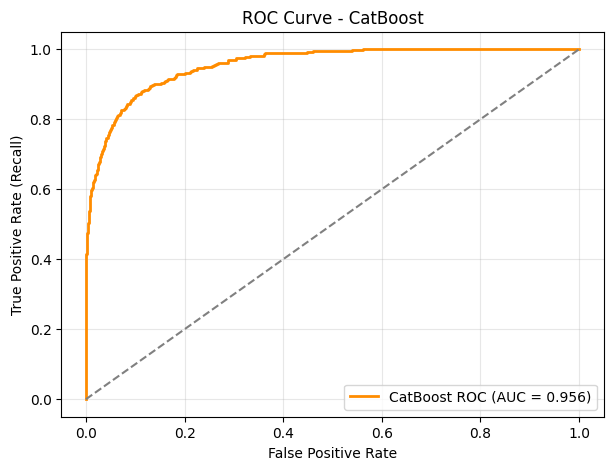

In [111]:
fpr_cb, tpr_cb, thr_cb = roc_curve(y_test, y_proba_cb)
roc_auc_cb = auc(fpr_cb, tpr_cb)

plt.figure(figsize=(7,5))
plt.plot(fpr_cb, tpr_cb, lw=2, color="darkorange",
         label=f"CatBoost ROC (AUC = {roc_auc_cb:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - CatBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

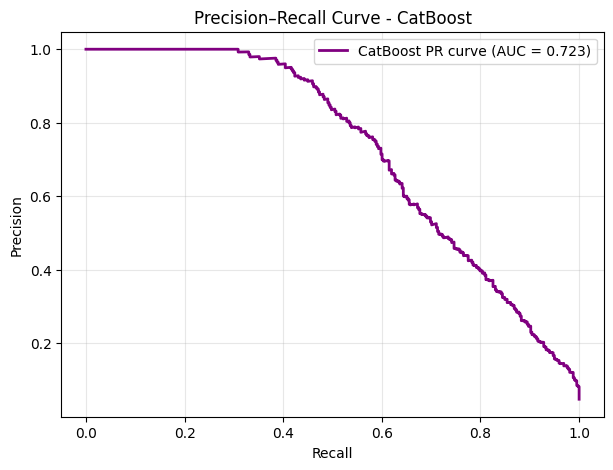

In [112]:
precision_cb, recall_cb, thr_pr_cb = precision_recall_curve(y_test, y_proba_cb)
pr_auc_cb = average_precision_score(y_test, y_proba_cb)

plt.figure(figsize=(7,5))
plt.plot(recall_cb, precision_cb, lw=2, color="purple",
         label=f"CatBoost PR curve (AUC = {pr_auc_cb:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - CatBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


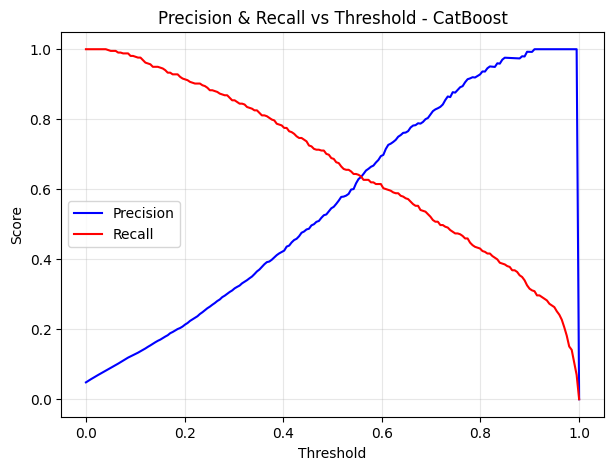

In [113]:
ths = np.linspace(0.0, 1.0, 200)
precisions = []
recalls = []

for t in ths:
    y_pred_t = (y_proba_cb >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t))

plt.figure(figsize=(7,5))
plt.plot(ths, precisions, label="Precision", color="blue")
plt.plot(ths, recalls, label="Recall", color="red")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold - CatBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [114]:
from sklearn.svm import SVC

model_svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=False,   
    random_state=42
)

model_svm.fit(X_train_res, y_train_res)

y_score_svm = model_svm.decision_function(X_test_scaled)

y_pred_svm = (y_score_svm >= 0).astype(int) 

print("SVM (RBF) Sonuçları\n")
print(classification_report(y_test, y_pred_svm, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

print("\nROC-AUC :", roc_auc_score(y_test, y_score_svm))
print("PR-AUC  :", average_precision_score(y_test, y_score_svm))


SVM (RBF) Sonuçları

              precision    recall  f1-score   support

           0      0.975     0.702     0.816      8263
           1      0.099     0.651     0.172       418

    accuracy                          0.699      8681
   macro avg      0.537     0.676     0.494      8681
weighted avg      0.933     0.699     0.785      8681

Confusion Matrix:
 [[5798 2465]
 [ 146  272]]

ROC-AUC : 0.7284050592744389
PR-AUC  : 0.12385710579313088


In [115]:
thresholds = [-2, -1, -0.5, 0, 0.5, 1, 2]

for t in thresholds:
    y_pred_t = (y_score_svm >= t).astype(int)
    print(f"\nThreshold (score) = {t}")
    print(classification_report(y_test, y_pred_t, digits=3))


Threshold (score) = -2
              precision    recall  f1-score   support

           0      0.991     0.027     0.052      8263
           1      0.049     0.995     0.094       418

    accuracy                          0.073      8681
   macro avg      0.520     0.511     0.073      8681
weighted avg      0.946     0.073     0.054      8681


Threshold (score) = -1
              precision    recall  f1-score   support

           0      0.989     0.202     0.335      8263
           1      0.057     0.955     0.108       418

    accuracy                          0.238      8681
   macro avg      0.523     0.578     0.222      8681
weighted avg      0.944     0.238     0.324      8681


Threshold (score) = -0.5
              precision    recall  f1-score   support

           0      0.982     0.437     0.605      8263
           1      0.070     0.840     0.130       418

    accuracy                          0.457      8681
   macro avg      0.526     0.638     0.367      8681


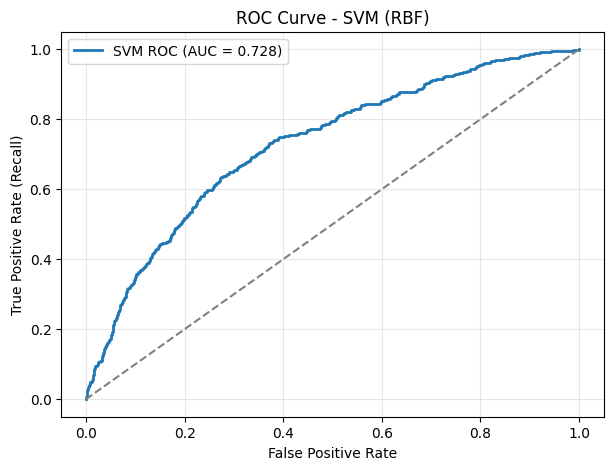

In [116]:
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(7,5))
plt.plot(fpr_svm, tpr_svm, lw=2, label=f"SVM ROC (AUC = {roc_auc_svm:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - SVM (RBF)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


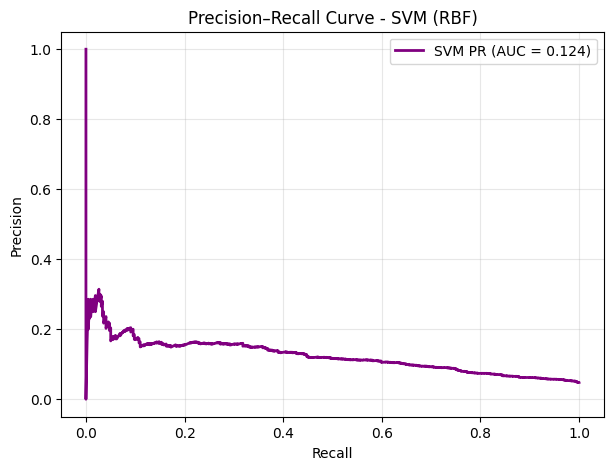

In [117]:
precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_score_svm)
pr_auc_svm = average_precision_score(y_test, y_score_svm)

plt.figure(figsize=(7,5))
plt.plot(recall_svm, precision_svm, lw=2, color="purple",
         label=f"SVM PR (AUC = {pr_auc_svm:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - SVM (RBF)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

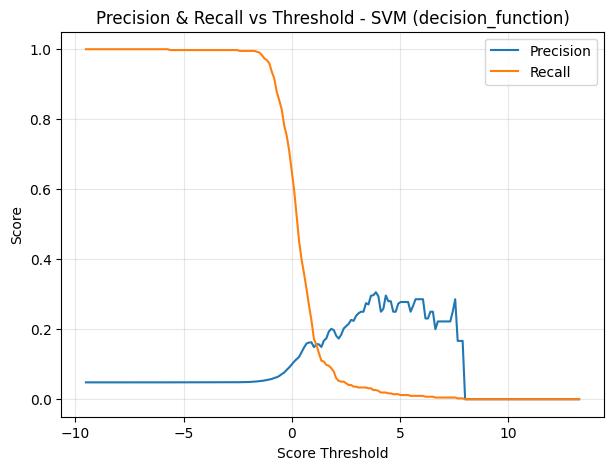

In [118]:
ths = np.linspace(np.min(y_score_svm), np.max(y_score_svm), 200)
precisions = []
recalls = []

for t in ths:
    y_pred_t = (y_score_svm >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t))

plt.figure(figsize=(7,5))
plt.plot(ths, precisions, label="Precision")
plt.plot(ths, recalls, label="Recall")
plt.xlabel("Score Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold - SVM (decision_function)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [119]:
from sklearn.neural_network import MLPClassifier

model_nn = MLPClassifier(
    hidden_layer_sizes=(100,), 
    activation="relu",
    solver="adam",  
    max_iter=1000,
    random_state=42
)

model_nn.fit(X_train_res, y_train_res)

y_proba_nn = model_nn.predict_proba(X_test_scaled)[:, 1]
y_pred_nn  = (y_proba_nn >= 0.5).astype(int)

print("\nSimple Neural Network Sonuçları\n")
print(classification_report(y_test, y_pred_nn, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nn))

print("\nROC-AUC :", roc_auc_score(y_test, y_proba_nn))
print("PR-AUC  :", average_precision_score(y_test, y_proba_nn))



Simple Neural Network Sonuçları

              precision    recall  f1-score   support

           0      0.974     0.923     0.948      8263
           1      0.252     0.514     0.338       418

    accuracy                          0.903      8681
   macro avg      0.613     0.719     0.643      8681
weighted avg      0.939     0.903     0.918      8681

Confusion Matrix:
 [[7625  638]
 [ 203  215]]

ROC-AUC : 0.8251034906862725
PR-AUC  : 0.2761936327449969


In [120]:
thresholds = [0.4, 0.3, 0.2, 0.1]

for t in thresholds:
    y_pred_t = (y_proba_nn >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred_t, digits=3))


Threshold = 0.4
              precision    recall  f1-score   support

           0      0.977     0.902     0.938      8263
           1      0.229     0.577     0.328       418

    accuracy                          0.886      8681
   macro avg      0.603     0.739     0.633      8681
weighted avg      0.941     0.886     0.908      8681


Threshold = 0.3
              precision    recall  f1-score   support

           0      0.980     0.876     0.925      8263
           1      0.207     0.639     0.312       418

    accuracy                          0.865      8681
   macro avg      0.593     0.757     0.619      8681
weighted avg      0.942     0.865     0.895      8681


Threshold = 0.2
              precision    recall  f1-score   support

           0      0.982     0.835     0.902      8263
           1      0.175     0.694     0.280       418

    accuracy                          0.828      8681
   macro avg      0.579     0.764     0.591      8681
weighted avg      0.943

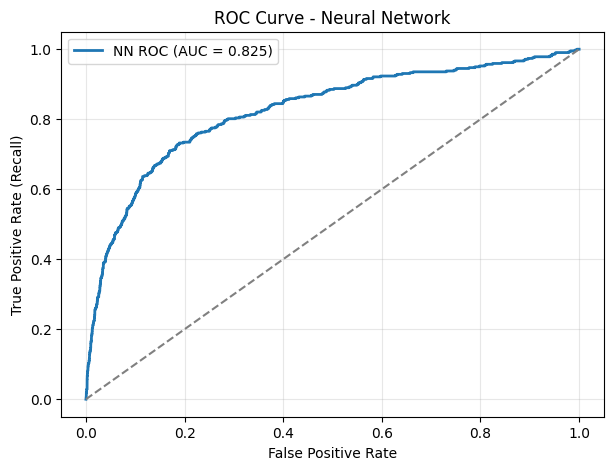

In [121]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr_nn, tpr_nn, thr_nn = roc_curve(y_test, y_proba_nn)
roc_auc_nn = auc(fpr_nn, tpr_nn)

plt.figure(figsize=(7,5))
plt.plot(fpr_nn, tpr_nn, lw=2, label=f"NN ROC (AUC = {roc_auc_nn:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Neural Network")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

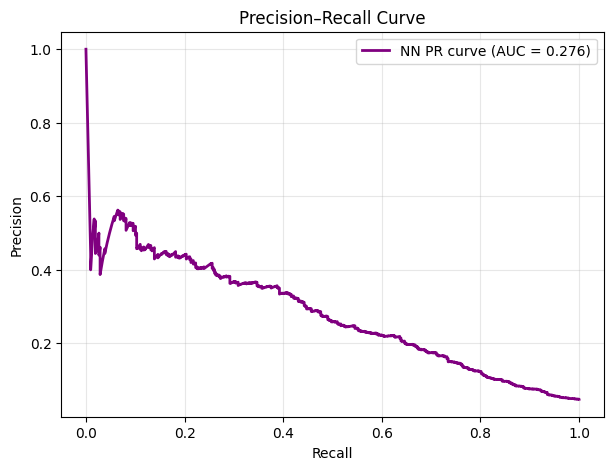

In [122]:
precision_nn, recall_nn, thr_pr_nn = precision_recall_curve(y_test, y_proba_nn)
pr_auc_nn = average_precision_score(y_test, y_proba_nn)

plt.figure(figsize=(7,5))
plt.plot(recall_nn, precision_nn, lw=2, color="purple",
         label=f"NN PR curve (AUC = {pr_auc_nn:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

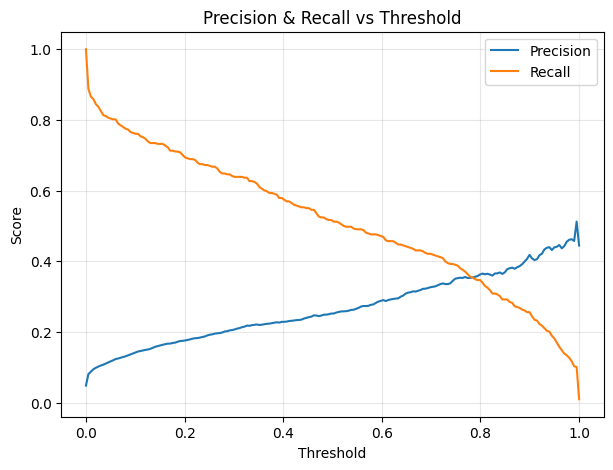

In [123]:
ths = np.linspace(0.0, 1.0, 200)
precisions = []
recalls = []

for t in ths:
    y_pred_t = (y_proba_nn >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t))

plt.figure(figsize=(7,5))
plt.plot(ths, precisions, label="Precision")
plt.plot(ths, recalls, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [124]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [125]:
model_cnn = Sequential([
    Dense(256, activation="relu", input_shape=(X_train_res.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])


model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR")
    ]
)

early_stop = EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model_cnn.fit(
    X_train_res, y_train_res,
    validation_split=0.2,
    epochs=100,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

y_proba_cnn = model_cnn.predict(X_test_scaled).ravel()
y_pred_cnn  = (y_proba_cnn >= 0.5).astype(int)

print("Complex Neural Network Sonuçları (threshold = 0.5)\n")
print(classification_report(y_test, y_pred_cnn, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_cnn))

print("\nROC-AUC :", roc_auc_score(y_test, y_proba_cnn))
print("PR-AUC  :", average_precision_score(y_test, y_proba_cnn))

c:\Users\ozgek\.conda\envs\tf310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - loss: 0.7029 - pr_auc: 0.4809 - roc_auc: 0.6146 - val_loss: 0.9696 - val_pr_auc: 1.0000 - val_roc_auc: 0.0000e+00
Epoch 2/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.6273 - pr_auc: 0.5651 - roc_auc: 0.6936 - val_loss: 0.9477 - val_pr_auc: 1.0000 - val_roc_auc: 0.0000e+00
Epoch 3/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.5972 - pr_auc: 0.5946 - roc_auc: 0.7283 - val_loss: 0.9340 - val_pr_auc: 1.0000 - val_roc_auc: 0.0000e+00
Epoch 4/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.5792 - pr_auc: 0.6152 - roc_auc: 0.7429 - val_loss: 0.9149 - val_pr_auc: 1.0000 - val_roc_auc: 0.0000e+00
Epoch 5/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.5645 - pr_auc: 0.6273 - roc_auc: 0.7584 - val_loss: 0.9171 - val_pr_auc: 1.0000 - val_roc_auc: 0.0000e+00
Epoch 6/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.5530 - pr_auc: 0.6427 - roc_auc: 0.7697 - val_loss: 0.9208 - val_pr_auc: 1.0000 - val

In [126]:
thresholds = [0.4, 0.3, 0.2, 0.1]

for t in thresholds:
    y_pred_t = (y_proba_cnn >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred_t, digits=3))


Threshold = 0.4
              precision    recall  f1-score   support

           0      0.958     0.975     0.966      8263
           1      0.232     0.148     0.181       418

    accuracy                          0.935      8681
   macro avg      0.595     0.562     0.574      8681
weighted avg      0.923     0.935     0.929      8681


Threshold = 0.3
              precision    recall  f1-score   support

           0      0.972     0.806     0.881      8263
           1      0.122     0.533     0.199       418

    accuracy                          0.793      8681
   macro avg      0.547     0.670     0.540      8681
weighted avg      0.931     0.793     0.848      8681


Threshold = 0.2
              precision    recall  f1-score   support

           0      0.990     0.398     0.568      8263
           1      0.072     0.919     0.133       418

    accuracy                          0.423      8681
   macro avg      0.531     0.658     0.350      8681
weighted avg      0.946

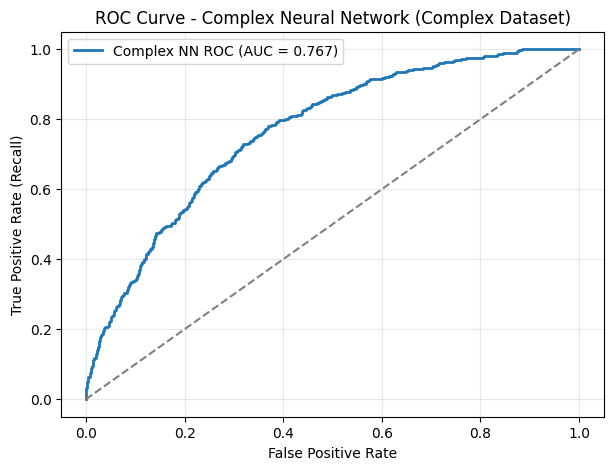

In [127]:
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_proba_cnn)
roc_auc_cnn = auc(fpr_cnn, tpr_cnn)

plt.figure(figsize=(7,5))
plt.plot(fpr_cnn, tpr_cnn, lw=2, label=f"Complex NN ROC (AUC = {roc_auc_cnn:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Complex Neural Network (Complex Dataset)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


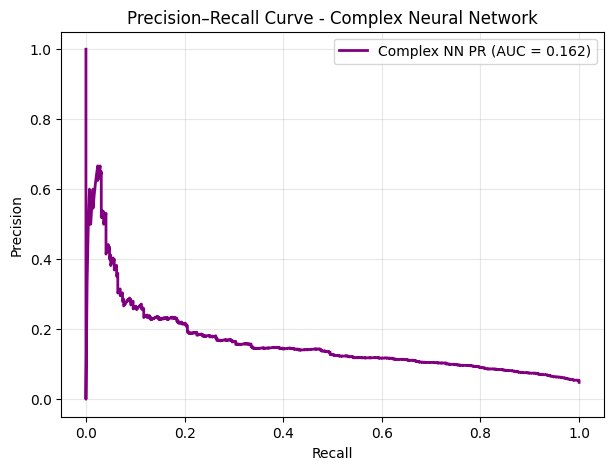

In [128]:
precision_cnn, recall_cnn, _ = precision_recall_curve(y_test, y_proba_cnn)
pr_auc_cnn = average_precision_score(y_test, y_proba_cnn)

plt.figure(figsize=(7,5))
plt.plot(recall_cnn, precision_cnn, lw=2, color="purple",
         label=f"Complex NN PR (AUC = {pr_auc_cnn:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - Complex Neural Network")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

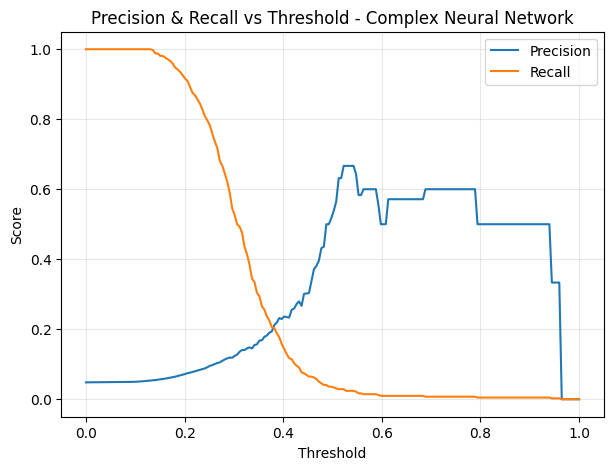

In [129]:
ths = np.linspace(0.0, 1.0, 200)
precisions = []
recalls = []

for t in ths:
    y_pred_t = (y_proba_cnn >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t))

plt.figure(figsize=(7,5))
plt.plot(ths, precisions, label="Precision")
plt.plot(ths, recalls, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold - Complex Neural Network")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [130]:
from sklearn.metrics import (precision_recall_fscore_support)


results = []

def add_model_result(name, y_test, y_pred, y_proba):
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=[1], average=None
    )
    results.append({
        "Model": name,
        "Precision_1": float(prec[0]),
        "Recall_1": float(rec[0]),
        "F1_1": float(f1[0]),
        "ROC_AUC": float(roc_auc_score(y_test, y_proba)),
        "PR_AUC": float(average_precision_score(y_test, y_proba))
    })

def pred_from_threshold(y_proba, thr):
    return (y_proba >= thr).astype(int)

THR = 0.4

add_model_result("Logistic Regression", y_test, y_pred_log, y_proba_log)
add_model_result(f"Logistic Regression (thr={THR})", y_test, pred_from_threshold(y_proba_log, THR), y_proba_log)

add_model_result("Random Forest", y_test, y_pred_rf, y_proba_rf)
add_model_result(f"Random Forest (thr={THR})", y_test, pred_from_threshold(y_proba_rf, THR), y_proba_rf)

add_model_result("XGBoost", y_test, y_pred_xgb, y_proba_xgb)
add_model_result(f"XGBoost (thr={THR})", y_test, pred_from_threshold(y_proba_xgb, THR), y_proba_xgb)

add_model_result("LightGBM", y_test, y_pred_lgbm, y_proba_lgbm)
add_model_result(f"LightGBM (thr={THR})", y_test, pred_from_threshold(y_proba_lgbm, THR), y_proba_lgbm)

add_model_result("SVM (RBF)", y_test, (y_score_svm >= 0.5).astype(int), y_score_svm)
add_model_result(f"SVM (thr={THR})", y_test, pred_from_threshold(y_score_svm, THR), y_score_svm)

add_model_result("CatBoost", y_test, y_pred_cb, y_proba_cb)
add_model_result(f"CatBoost (thr={THR})", y_test, pred_from_threshold(y_proba_cb, THR), y_proba_cb)

add_model_result("Simple NN", y_test, y_pred_nn, y_proba_nn)

add_model_result("Complex NN", y_test, y_pred_cnn, y_proba_cnn)

df_results = pd.DataFrame(results)
df_results = df_results.sort_values("F1_1", ascending=False).reset_index(drop=True)

print(df_results)


                            Model  Precision_1  Recall_1      F1_1   ROC_AUC  \
0                        LightGBM     0.847305  0.677033  0.752660  0.975731   
1              LightGBM (thr=0.4)     0.759494  0.717703  0.738007  0.975731   
2                         XGBoost     0.700957  0.700957  0.700957  0.964367   
3               XGBoost (thr=0.4)     0.573770  0.753589  0.651499  0.964367   
4                        CatBoost     0.548571  0.688995  0.610817  0.956073   
5              CatBoost (thr=0.4)     0.425587  0.779904  0.550676  0.956073   
6                   Random Forest     0.523918  0.550239  0.536756  0.927594   
7         Random Forest (thr=0.4)     0.372881  0.684211  0.482700  0.927594   
8                       Simple NN     0.252052  0.514354  0.338316  0.825103   
9                       SVM (RBF)     0.138354  0.377990  0.202564  0.728405   
10                  SVM (thr=0.4)     0.130466  0.428230  0.200000  0.728405   
11            Logistic Regression     0.

In [131]:
idx_rec = df_results["Recall_1"].idxmax()
print("\nEn yüksek Recall_1:")
print(df_results.loc[idx_rec, ["Model", "Recall_1"]])

idx_pr = df_results["PR_AUC"].idxmax()
print("\nEn yüksek PR-AUC:")
print(df_results.loc[idx_pr, ["Model", "PR_AUC"]])

idx_f1 = df_results["F1_1"].idxmax()
print("\nEn yüksek F1_1:")
print(df_results.loc[idx_f1, ["Model", "F1_1", "Recall_1", "Precision_1", "PR_AUC", "ROC_AUC"]])


En yüksek Recall_1:
Model       Logistic Regression (thr=0.4)
Recall_1                         0.844498
Name: 12, dtype: object

En yüksek PR-AUC:
Model     LightGBM
PR_AUC    0.825864
Name: 0, dtype: object

En yüksek F1_1:
Model          LightGBM
F1_1            0.75266
Recall_1       0.677033
Precision_1    0.847305
PR_AUC         0.825864
ROC_AUC        0.975731
Name: 0, dtype: object


In [132]:
idx_f1 = df_results["F1_1"].idxmax()
best_model_name = df_results.loc[idx_f1, "Model"]
print("Best Model (by F1):", best_model_name)

Best Model (by F1): LightGBM


In [133]:
THR = 0.4
best_model_name = df_results.loc[idx_f1, "Model"]
print("Best model:", best_model_name)

# -------------------------
# LightGBM
# -------------------------
if "LightGBM" in best_model_name:
    best_y_proba = y_proba_lgbm
    if "(thr=" in best_model_name:
        best_y_pred = (best_y_proba >= THR).astype(int)
    else:
        best_y_pred = y_pred_lgbm

# -------------------------
# XGBoost
# -------------------------
elif "XGBoost" in best_model_name:
    best_y_proba = y_proba_xgb
    if "(thr=" in best_model_name:
        best_y_pred = (best_y_proba >= THR).astype(int)
    else:
        best_y_pred = y_pred_xgb

# -------------------------
# Random Forest
# -------------------------
elif "Random Forest" in best_model_name:
    best_y_proba = y_proba_rf
    if "(thr=" in best_model_name:
        best_y_pred = (best_y_proba >= THR).astype(int)
    else:
        best_y_pred = y_pred_rf

# -------------------------
# CatBoost
# -------------------------
elif "CatBoost" in best_model_name:
    best_y_proba = y_proba_cb
    if "(thr=" in best_model_name:
        best_y_pred = (best_y_proba >= THR).astype(int)
    else:
        best_y_pred = y_pred_cb

# -------------------------
# Logistic Regression
# -------------------------
elif "Logistic Regression" in best_model_name:
    best_y_proba = y_proba_log
    if "(thr=" in best_model_name:
        best_y_pred = (best_y_proba >= THR).astype(int)
    else:
        best_y_pred = y_pred_log

# -------------------------
# SVM
# -------------------------
elif "SVM" in best_model_name:
    best_y_proba = y_score_svm
    if "(thr=" in best_model_name:
        best_y_pred = (best_y_proba >= THR).astype(int)
    else:
        best_y_pred = (best_y_proba >= 0.5).astype(int)

# -------------------------
# Neural Networks
# -------------------------
elif "Simple NN" in best_model_name:
    best_y_proba = y_proba_nn
    best_y_pred  = y_pred_nn

elif "Complex NN" in best_model_name:
    best_y_proba = y_proba_cnn
    best_y_pred  = y_pred_cnn

else:
    raise ValueError("Best model eşleştirilemedi")


Best model: LightGBM


In [134]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, best_y_pred))

print("\nClassification Report:")
print(classification_report(y_test, best_y_pred, digits=3))

Confusion Matrix:
[[8212   51]
 [ 135  283]]

Classification Report:
              precision    recall  f1-score   support

           0      0.984     0.994     0.989      8263
           1      0.847     0.677     0.753       418

    accuracy                          0.979      8681
   macro avg      0.916     0.835     0.871      8681
weighted avg      0.977     0.979     0.977      8681



In [135]:
from sklearn.metrics import f1_score

ths = np.linspace(0, 1, 501)
f1s = [f1_score(y_test, (best_y_proba >= t).astype(int)) for t in ths]

best_thr = ths[int(np.argmax(f1s))]
print("Best threshold (max F1):", best_thr, "Best F1:", max(f1s))

Best threshold (max F1): 0.47600000000000003 Best F1: 0.7559055118110236


In [136]:
best_y_pred_opt = (best_y_proba >= best_thr).astype(int)

print("Confusion Matrix (opt thr):")
print(confusion_matrix(y_test, best_y_pred_opt))

print("\nClassification Report (opt thr):")
print(classification_report(y_test, best_y_pred_opt, digits=3))

Confusion Matrix (opt thr):
[[8207   56]
 [ 130  288]]

Classification Report (opt thr):
              precision    recall  f1-score   support

           0      0.984     0.993     0.989      8263
           1      0.837     0.689     0.756       418

    accuracy                          0.979      8681
   macro avg      0.911     0.841     0.872      8681
weighted avg      0.977     0.979     0.978      8681



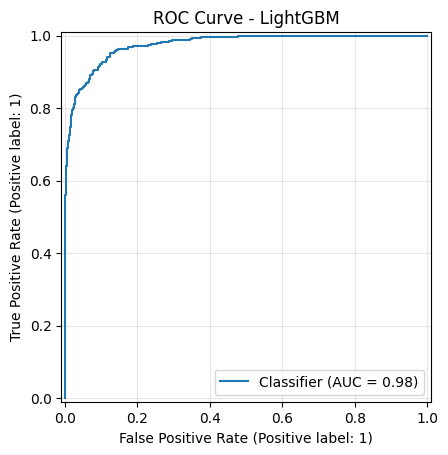

In [137]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, best_y_proba)
plt.title(f"ROC Curve - {best_model_name}")
plt.grid(alpha=0.3)
plt.show()

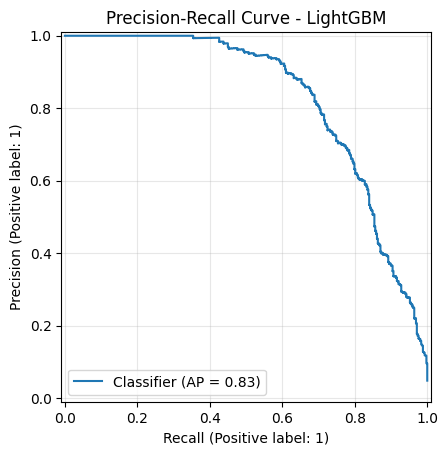

In [138]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, best_y_proba)
plt.title(f"Precision-Recall Curve - {best_model_name}")
plt.grid(alpha=0.3)
plt.show()

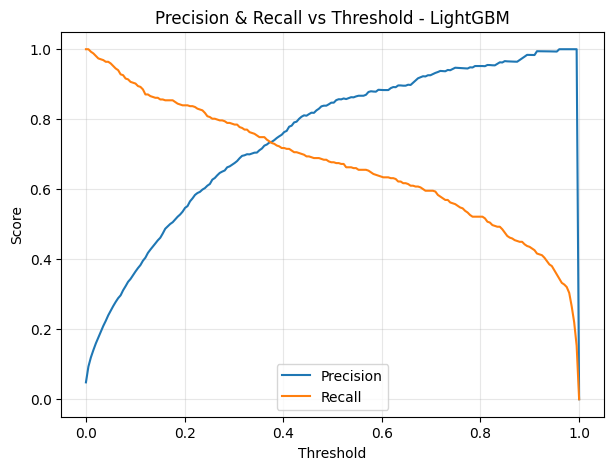

In [139]:
ths = np.linspace(0.0, 1.0, 200)
precisions, recalls = [], []

for t in ths:
    y_pred_t = (best_y_proba >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t))

plt.figure(figsize=(7,5))
plt.plot(ths, precisions, label="Precision")
plt.plot(ths, recalls, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title(f"Precision & Recall vs Threshold - {best_model_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [140]:
!pip install seaborn

In [141]:
model_map = {
    "LightGBM": model_lgbm,
    "XGBoost": model_xgb,
    "Random Forest": model_rf,
    "CatBoost": model_cb,
    "Logistic Regression": model_log_reg,
    "SVM": model_svm,
    "Simple NN": model_nn,
    "Complex NN": model_cnn,
}

best_model = model_map[best_model_name]

In [142]:
feature_names = X_train_imp.columns.tolist()
feature_names = ["Year"] + feature_names

def plot_feature_importance(model, feature_names, top_n=20):
    if hasattr(model, "named_steps"):
        model = model.named_steps[list(model.named_steps.keys())[-1]]

    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_).ravel()
    else:
        print("Bu model feature importance desteklemiyor.")
        return

    if len(importances) != len(feature_names):
        print("Feature sayısı uyuşmuyor!",
              "importances:", len(importances),
              "features:", len(feature_names))
        return

    feature_imp = (
        pd.DataFrame({"Feature": feature_names, "Value": importances})
        .sort_values("Value", ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(10, 8))
    sns.barplot(x="Value", y="Feature", data=feature_imp)
    plt.title(f"Top {top_n} Feature Importances - {best_model_name}")
    plt.tight_layout()
    plt.show()


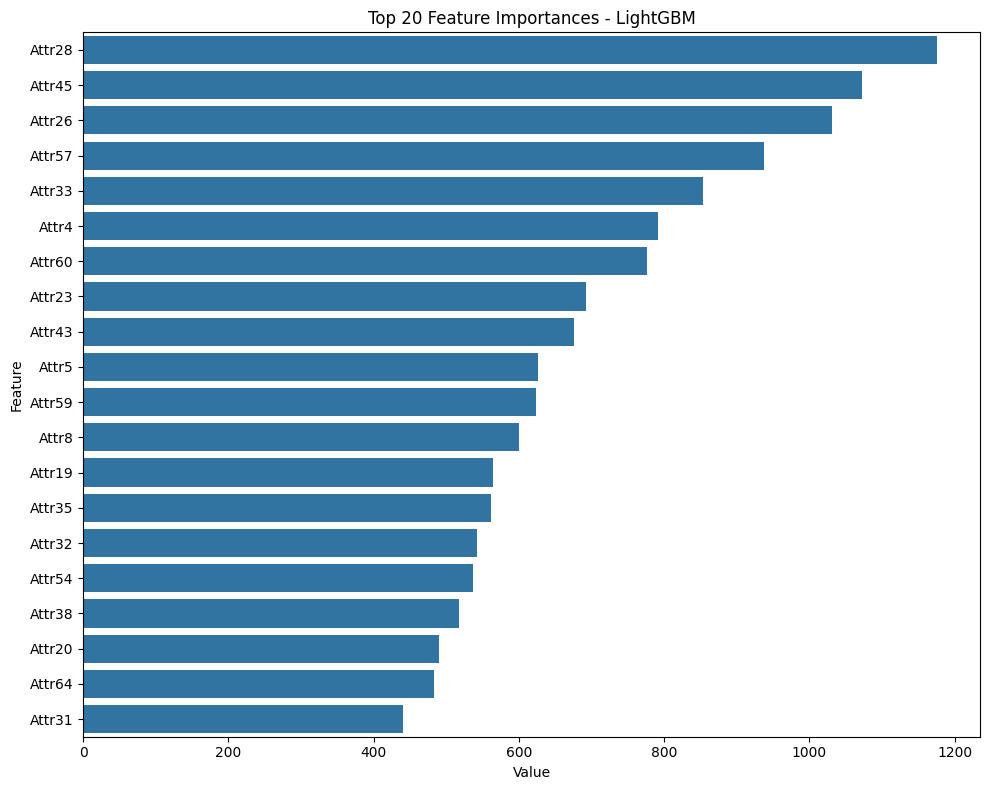

In [143]:
plot_feature_importance(best_model, feature_names, top_n=20)


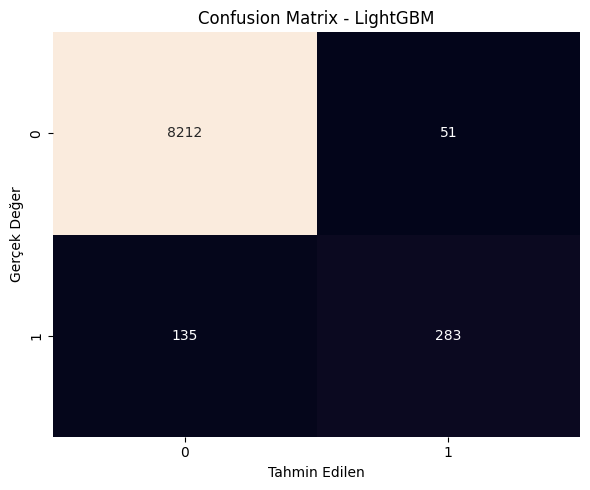

In [144]:
cm = confusion_matrix(y_test, best_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cbar=False)
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek Değer")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()